In [3]:
# torchvision과 torchaudio를 추가하여 torch 버전과 호환되도록 함께 업데이트합니다.
# !pip -q install -U "torch>=2.2,<3.0" "torchvision" "torchaudio" "datasets>=3.0.1" "transformers>=4.45.2" "accelerate>=1.0.1" "evaluate>=0.4.2"


import torch, transformers, datasets, evaluate
import numpy as np


print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
print("Transformers:", transformers.__version__, "| Datasets:", datasets.__version__)


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

/home/kim/miniconda3/envs/ai_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0+cu130 | CUDA: True
Transformers: 5.2.0 | Datasets: 4.5.0
Using device: cuda


In [4]:
from datasets import load_dataset
beans=load_dataset("beans")
print(beans)

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'image', 'labels'],
        num_rows: 128
    })
})


In [5]:
beans['train'].features['labels'].names

['angular_leaf_spot', 'bean_rust', 'healthy']

In [6]:
from transformers import AutoImageProcessor, ViTForImageClassification
import torch


# 모델 및 프로세서 설정
MODEL = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(MODEL)

# 라벨 매핑 설정
key = 'labels' if 'labels' in beans['train'].features else 'label'
names = beans['train'].features[key].names
id2label = {i: n for i, n in enumerate(names)}
label2id = {n: i for i, n in enumerate(names)}

# 모델 로드
model = ViTForImageClassification.from_pretrained(
    MODEL,
    num_labels=len(names),
    id2label = id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1709.15it/s, Materializing param=vit.layernorm.weight]                                 
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match 

In [7]:
model.classifier.out_features

3

In [8]:
import os

num_proc = os.cpu_count()
num_proc

def transform(ex):
    # 입력이 PIL 이미지 리스트 (batched=True)
    # processor 가 알아서 resize, 정규화 수행, tensor 변환
    inputs = processor(images=ex['image'], return_tensors='pt')
    # 이미지 리스트를 프로세서에 전달

    ex['pixel_values'] = inputs['pixel_values']
    # pixel_values : 4차원 텐서로 출력 (b,c,h,w)
    # 입력된 이미지의 픽셀 값만 추출 >> 배치에 추가
    return ex

# 먼저 map 전처리 수행 (병렬 처리 추가)
# remove_columns 사용, 원본 image 컬럼 제거 (메모리 절약)

beans = beans.map(
    transform,
    batched=True,
    remove_columns=['image'],
    num_proc=num_proc,
)

# format 설정
# Hugging Face Trainer 쓰면 이 부분 생략 >> 대신 DataCollater가 처리하게 함
beans.set_format('torch')

Map (num_proc=20):   0%|          | 0/1034 [00:00<?, ? examples/s]

Map (num_proc=20): 100%|██████████| 128/128 [00:00<00:00, 315.38 examples/s]


In [11]:
def keep(split):
    cols = ['pixel_values', key]
    # pixel_values 이미지 데이터, key: 라벨
    # 즉, cols는 이미지데이터, 라벨을 남기겠다.
    # split : train, val, test
    return beans[split].remove_columns([c for c in beans[split].column_names if c not in cols])
# 지울 컬럼리스트 = 전체 컬럼 - 남길 컬럼

In [9]:
beans

DatasetDict({
    train: Dataset({
        features: ['image_file_path', 'labels', 'pixel_values'],
        num_rows: 1034
    })
    validation: Dataset({
        features: ['image_file_path', 'labels', 'pixel_values'],
        num_rows: 133
    })
    test: Dataset({
        features: ['image_file_path', 'labels', 'pixel_values'],
        num_rows: 128
    })
})

In [12]:
train, validation, test = keep('train'), keep('validation'), keep('test')

In [13]:
from transformers import TrainingArguments, Trainer, DefaultDataCollator
import evaluate
import numpy as np
import torch


# 정확도 지표 로드
acc = evaluate.load("accuracy")

# 평가 계산 함수 정의
def metrics(p):
    predictions, labels = p
    pred = np.argmax(predictions, axis=1)
    return {'accuracy': acc.compute(predictions=pred, references=labels)['accuracy']}

# TrainingArguments 설정
args = TrainingArguments(
    output_dir='./data/vit_beans',
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=2e-5,
    fp16=torch.cuda.is_available(),
    report_to='none',
    remove_unused_columns=False,
)

# Trainer 초기화
# tokenizer=processor >> 이것 대신에 data_collater 명시하는 게 정석임
trainer = Trainer(
    model = model,
    args=args,
    train_dataset=train,
    eval_dataset=validation,
    data_collator=DefaultDataCollator(),
    compute_metrics=metrics
)

# DefaultDataCollator()
# 각 개별 샘플들을 하나씩 깔끔하게 배치(batch) tensor 로 묶어주는 역할

In [14]:
# 학습 시작
trainer.train()

print(trainer.evaluate(test))

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.119688,0.962406
2,No log,0.043972,0.977444
3,No log,0.036162,0.984962


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.33it/s]


{'eval_loss': 0.07561813294887543, 'eval_accuracy': 0.9765625, 'eval_runtime': 0.4935, 'eval_samples_per_second': 259.391, 'eval_steps_per_second': 8.106, 'epoch': 3.0}


In [17]:
import torch

for i in [0,1]:
    ex = beans['test'][i]

    input_tensor = ex['pixel_values'].clone().detach()
    inputs = input_tensor.unsqueeze(0).to(model.device)

    with torch.no_grad():
        logits = model(inputs).logits
        pred = logits.argmax(-1).item()

    # 정답 라벨 가져오기
    label_key = 'labels' if 'labels' in ex else 'label'

    true_label_id = ex[label_key].item()
    # 결과 출력
    print(f'[{i} 예측: {model.config.id2label[pred]} | {model.config.id2label[true_label_id]}]')

[0 예측: angular_leaf_spot | angular_leaf_spot]
[1 예측: angular_leaf_spot | angular_leaf_spot]


In [20]:
a = beans['test'][0]['pixel_values'].clone().detach()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.92156863].


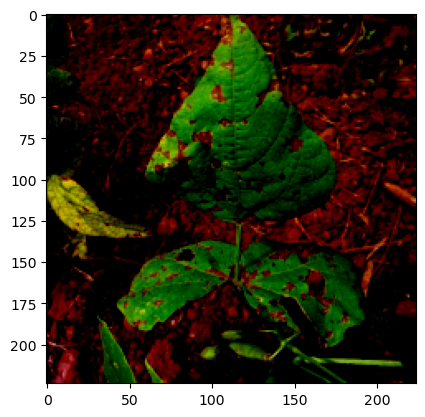

In [25]:
import matplotlib.pyplot as plt
plt.imshow(a.cpu().numpy().transpose(1,2,0))